In [2]:
import tensorflow as tf
import skimage
import sklearn
from tensorflow import keras
from tensorflow.keras.models import load_model
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import os
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

# Tải các mô hình đã train
model_1 = load_model('./models3/ckpt_vgg16/fold_1_checkpoint_5.model.keras')
model_2 = load_model('./models3/ckpt_resnet50/fold_3_checkpoint_5.model.keras')
model_3 = load_model('./models3/ckpt_inceptionv3/fold_3_checkpoint_5.model.keras')

In [3]:
o_data_path = r'C:/Dat/Research/Final/PhotoTrain/train'  
o_test_path = r'C:/Dat/Research/Final/PhotoTrain/test'    


In [4]:
def create_dataframe(data_path):
    filepaths = []
    labels = []

    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.lower().endswith(('png', 'jpg', 'jpeg')):  # Chỉ lấy ảnh
                full_path = os.path.join(root, file)  # Đường dẫn đầy đủ

                filepaths.append(full_path)
                labels.append(os.path.basename(root))  # Nhãn là tên thư mục cha

    dataframe = pd.DataFrame({'filepath': filepaths, 'label': labels})
    return dataframe


In [5]:
batch_size = 10
img_size = (224, 224)

In [6]:
dataframe = create_dataframe(o_data_path)

datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input)

test_batches = datagen.flow_from_directory(
    directory=o_test_path,
    target_size=img_size,
    classes=['normal', 'bengin', 'acancer', 'lcancer', 'scancer'],
    batch_size=batch_size,
    shuffle=False
)

Found 21990 images belonging to 5 classes.


**Test**

In [6]:
img = cv2.imread(r"C:\Users\Thanh Dat\Pictures\bengin.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (224, 224))

# Preprocess for VGG16
resized_input = preprocess_input(img_resized)
resized_input = np.expand_dims(resized_input, axis=0)

# Make prediction
prediction = model_1.predict(resized_input)
predicted_class = np.argmax(prediction, axis=1)

# Define labels
labels = ['normal', 'bengin', 'acancer', 'lcancer', 'scancer']
decoded_prediction = labels[predicted_class[0]]

# Convert probabilities to percentages
percentages = prediction[0] * 100
percentages = np.round(percentages, 2)

# Display the result
print("Prediction probabilities (%):")
for label, percent in zip(labels, percentages):
    print(f"{label}: {percent}%")

print("Predicted class:", decoded_prediction)


1/1 [==============================] - 0s 54ms/step
Prediction probabilities (%):
normal: 0.09000000357627869%
bengin: 99.30999755859375%
acancer: 0.019999999552965164%
lcancer: 0.49000000953674316%
scancer: 0.09000000357627869%
Predicted class: bengin


2199/2199 [==============================] - 302s 131ms/step
Accuracy: 0.9848
Confusion matrix, without normalization
[[4334    0    0    0   64]
 [   0 4354   23   21    0]
 [   0   28 4320   50    0]
 [   0   51   52 4291    4]
 [  41    0    1    0 4356]]


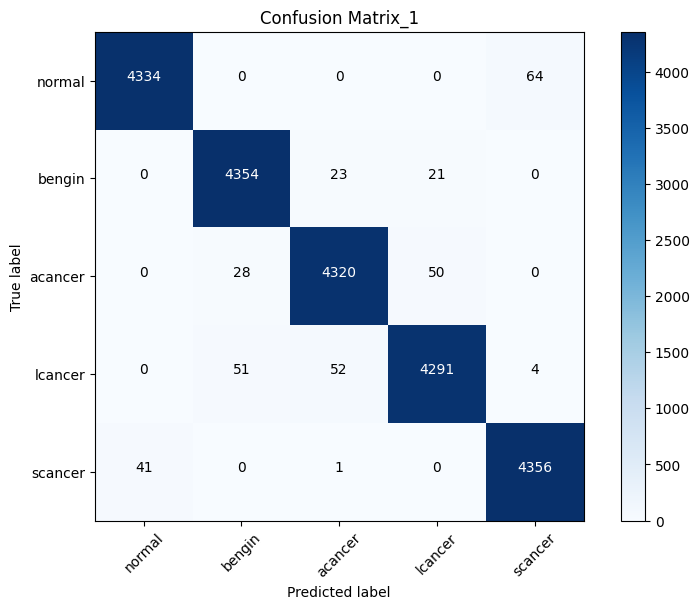

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt


predictions = model_1.predict(x=test_batches, verbose=1)
y_true = test_batches.classes
y_pred = np.argmax(predictions, axis=-1)

accuracy = accuracy_score(y_true, y_pred)
print(f'Accuracy: {accuracy:.4f}') 

labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_true=y_true, y_pred=y_pred, labels=labels)

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f'{cm[i, j]}',
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

cm_plot_labels = ['normal', 'bengin', 'acancer', 'lcancer', 'scancer']
plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title='Confusion Matrix_1')


In [1]:
import tensorflow as tf
import numpy as np
import cv2
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import load_model

model_1 = load_model('./models3/ckpt_vgg16/fold_1_checkpoint_5.model.keras')

def check_cancer(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))

    resized_input = preprocess_input(img_resized)
    resized_input = np.expand_dims(resized_input, axis=0)

    prediction = model_1.predict(resized_input)
    predicted_class = np.argmax(prediction, axis=1)

    labels = ['normal', 'bengin', 'acancer', 'lcancer', 'scancer']
    decoded_prediction = labels[predicted_class[0]]

    percentages = prediction[0] * 100
    percentages = np.round(percentages, 2)

    print("Prediction probabilities (%):")
    for label, percent in zip(labels, percentages):
        print(f"{label}: {percent}%")

    print("Predicted class:", decoded_prediction)


In [ ]:
img_path = r"C:\Users\Thanh Dat\Pictures\4c1383482027c97c445f418c9b74b3.jpg"
check_cancer(img_path)